# 🏢 End-to-End Customer Analytics & Revenue Forecasting Project Using Python

**Dataset:** `subscription_data.csv` | 2,560 rows × 15 columns  
**Target Variable:** `total_revenue` (Linear Regression — Revenue Prediction)  
**Model:** Linear Regression

---

## 📋 Table of Contents
1. [Problem Statement](#1)
2. [Import Libraries](#2)
3. [Load Dataset](#3)
4. [Data Cleaning](#4)
5. [Feature Engineering](#5)
6. [Visualizations — EDA](#6)
7. [Modeling — Linear Regression](#7)
8. [Predict Revenue for New Customer](#8)


## 1️⃣ Problem Statement <a id='1'></a>

### 🏢 Business Context
A subscription-based digital services company wants to understand customer behavior, improve revenue, and reduce churn. The company collects customer demographic, subscription, usage, and marketing data but has not yet fully leveraged this data for decision-making.

### 🎯 Objective
- Clean and prepare raw customer subscription data  
- Engineer meaningful features to capture customer behavior and value  
- Analyze patterns that influence revenue and churn  
- Build a predictive **Linear Regression model** to estimate future customer revenue  

### ❓ Key Business Questions
- What customer characteristics contribute most to revenue?  
- How do tenure, plan type, discounts, and usage affect revenue?  
- Are certain customer segments more valuable than others?  
- Can we reliably predict future revenue using historical data?  

### ✅ Expected Outcome
- A clean, analysis-ready dataset  
- Actionable insights for business decision-makers  
- A revenue prediction model to assist in strategic planning  

---

## 📋 Dataset Columns (Total = 15)

| Category | Columns |
|---|---|
| **Customer Info** | customer_id, age, gender, city |
| **Dates** | signup_date, last_active_date |
| **Subscription** | plan_type, monthly_fee, tenure_months |
| **Usage & Support** | support_tickets, avg_session_time |
| **Marketing & Retention** | discount_percent, marketing_channel, churned |
| **Target (Regression)** | total_revenue |


## 2️⃣ Import Libraries <a id='2'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings


## 3️⃣ Load Dataset <a id='3'></a>

In [2]:
df = pd.read_csv('subscription_data.csv')
df

,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue
0,10001,56.0,Female,Chennai,12/3/2022,12/29/2022,Basic,1214,25,5,15.75,15.0,Referral,Yes,30167.90
1,10002,46.0,Female,Mumbai,3/24/2021,1/25/2022,Premium,1268,22,1,37.16,20.0,Organic,Yes,27642.40
2,10003,32.0,Female,Mumbai,6/15/2023,8/10/2023,Basic,783,4,0,41.93,5.0,Referral,No,3092.85
3,10004,60.0,Male,Delhi,11/13/2022,7/8/2021,Standard,545,4,1,116.41,0.0,Organic,No,2180.00
4,10005,25.0,Female,Mumbai,2/17/2022,6/25/2021,Basic,1331,30,1,81.89,10.0,Ads,No,39796.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,11315,61.0,Male,Bangalore,11/17/2021,10/15/2022,Basic,1194,17,1,78.57,20.0,Organic,No,20059.20
2556,10645,25.0,Female,Pune,1/15/2022,11/3/2023,Basic,1016,18,2,9.21,NaN,Email,No,18288.00
2557,12103,25.0,Female,Chennai,1/21/2022,8/14/2022,Premium,801,20,1,11.67,20.0,Organic,No,15859.80
2558,10615,NaN,Female,Pune,3/17/2022,10/7/2023,Premium,692,22,0,34.42,0.0,Ads,No,15224.00


## 4️⃣ Data Cleaning <a id='4'></a>

### Step-by-Step Cleaning Process

### Q1. How many rows and columns are present in the dataset?

In [3]:
# rows , columns
df.shape

(2560, 15)

### Q2. What are the data types of each column?

In [4]:
df.dtypes

customer_id            int64
age                  float64
gender                object
city                  object
signup_date           object
last_active_date      object
plan_type             object
monthly_fee            int64
tenure_months          int64
support_tickets        int64
avg_session_time     float64
discount_percent     float64
marketing_channel     object
churned               object
total_revenue        float64
dtype: object

### Q3. Which columns contain missing values?

In [5]:
df.isna().sum()

customer_id            0
age                  105
gender                 0
city                 104
signup_date            0
last_active_date       0
plan_type              0
monthly_fee            0
tenure_months          0
support_tickets        0
avg_session_time     101
discount_percent     105
marketing_channel      0
churned                0
total_revenue          0
dtype: int64

### Q4. What percentage of missing values does each column have?

In [6]:
((df.isna().sum()) / len(df)) * 100

customer_id          0.000000
age                  4.101562
gender               0.000000
city                 4.062500
signup_date          0.000000
last_active_date     0.000000
plan_type            0.000000
monthly_fee          0.000000
tenure_months        0.000000
support_tickets      0.000000
avg_session_time     3.945312
discount_percent     4.101562
marketing_channel    0.000000
churned              0.000000
total_revenue        0.000000
dtype: float64

### Q5. How should missing values in the `age` column be handled?
> **→ Fill with Median** (age is numeric and may be skewed — median is robust)

In [7]:
print("Median of age:", df["age"].median())
df["age"] = df["age"].fillna(df["age"].median())
df

Median of age: 41.0


,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue
0,10001,56.0,Female,Chennai,12/3/2022,12/29/2022,Basic,1214,25,5,15.75,15.0,Referral,Yes,30167.90
1,10002,46.0,Female,Mumbai,3/24/2021,1/25/2022,Premium,1268,22,1,37.16,20.0,Organic,Yes,27642.40
2,10003,32.0,Female,Mumbai,6/15/2023,8/10/2023,Basic,783,4,0,41.93,5.0,Referral,No,3092.85
3,10004,60.0,Male,Delhi,11/13/2022,7/8/2021,Standard,545,4,1,116.41,0.0,Organic,No,2180.00
4,10005,25.0,Female,Mumbai,2/17/2022,6/25/2021,Basic,1331,30,1,81.89,10.0,Ads,No,39796.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,11315,61.0,Male,Bangalore,11/17/2021,10/15/2022,Basic,1194,17,1,78.57,20.0,Organic,No,20059.20
2556,10645,25.0,Female,Pune,1/15/2022,11/3/2023,Basic,1016,18,2,9.21,NaN,Email,No,18288.00
2557,12103,25.0,Female,Chennai,1/21/2022,8/14/2022,Premium,801,20,1,11.67,20.0,Organic,No,15859.80
2558,10615,41.0,Female,Pune,3/17/2022,10/7/2023,Premium,692,22,0,34.42,0.0,Ads,No,15224.00


### Q6. How do you handle missing values in the `city` column?
> **→ Fill with Mode** (most frequent city)

In [8]:
print("Mode of city:", df["city"].mode()[0])
df["city"] = df["city"].fillna(df["city"].mode()[0])
df

Mode of city: Mumbai


,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue
0,10001,56.0,Female,Chennai,12/3/2022,12/29/2022,Basic,1214,25,5,15.75,15.0,Referral,Yes,30167.90
1,10002,46.0,Female,Mumbai,3/24/2021,1/25/2022,Premium,1268,22,1,37.16,20.0,Organic,Yes,27642.40
2,10003,32.0,Female,Mumbai,6/15/2023,8/10/2023,Basic,783,4,0,41.93,5.0,Referral,No,3092.85
3,10004,60.0,Male,Delhi,11/13/2022,7/8/2021,Standard,545,4,1,116.41,0.0,Organic,No,2180.00
4,10005,25.0,Female,Mumbai,2/17/2022,6/25/2021,Basic,1331,30,1,81.89,10.0,Ads,No,39796.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,11315,61.0,Male,Bangalore,11/17/2021,10/15/2022,Basic,1194,17,1,78.57,20.0,Organic,No,20059.20
2556,10645,25.0,Female,Pune,1/15/2022,11/3/2023,Basic,1016,18,2,9.21,NaN,Email,No,18288.00
2557,12103,25.0,Female,Chennai,1/21/2022,8/14/2022,Premium,801,20,1,11.67,20.0,Organic,No,15859.80
2558,10615,41.0,Female,Pune,3/17/2022,10/7/2023,Premium,692,22,0,34.42,0.0,Ads,No,15224.00


### Q7. How to treat missing values in `avg_session_time`?
> **→ Fill with Mean** (continuous metric, mean is appropriate)

In [9]:
print("Mean of avg_session_time:", df["avg_session_time"].mean())
df["avg_session_time"] = df["avg_session_time"].fillna(df["avg_session_time"].mean())
df

Mean of avg_session_time: 62.71956893045953


,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue
0,10001,56.0,Female,Chennai,12/3/2022,12/29/2022,Basic,1214,25,5,15.75,15.0,Referral,Yes,30167.90
1,10002,46.0,Female,Mumbai,3/24/2021,1/25/2022,Premium,1268,22,1,37.16,20.0,Organic,Yes,27642.40
2,10003,32.0,Female,Mumbai,6/15/2023,8/10/2023,Basic,783,4,0,41.93,5.0,Referral,No,3092.85
3,10004,60.0,Male,Delhi,11/13/2022,7/8/2021,Standard,545,4,1,116.41,0.0,Organic,No,2180.00
4,10005,25.0,Female,Mumbai,2/17/2022,6/25/2021,Basic,1331,30,1,81.89,10.0,Ads,No,39796.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,11315,61.0,Male,Bangalore,11/17/2021,10/15/2022,Basic,1194,17,1,78.57,20.0,Organic,No,20059.20
2556,10645,25.0,Female,Pune,1/15/2022,11/3/2023,Basic,1016,18,2,9.21,NaN,Email,No,18288.00
2557,12103,25.0,Female,Chennai,1/21/2022,8/14/2022,Premium,801,20,1,11.67,20.0,Organic,No,15859.80
2558,10615,41.0,Female,Pune,3/17/2022,10/7/2023,Premium,692,22,0,34.42,0.0,Ads,No,15224.00


### Q8. How to handle missing values in `discount_percent`?
> **→ Fill with Mean**

In [10]:
print("Mean of discount_percent:", df["discount_percent"].mean())
df["discount_percent"] = df["discount_percent"].fillna(df["discount_percent"].mean())
df

Mean of discount_percent: 10.024439918533606


,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue
0,10001,56.0,Female,Chennai,12/3/2022,12/29/2022,Basic,1214,25,5,15.75,15.00000,Referral,Yes,30167.90
1,10002,46.0,Female,Mumbai,3/24/2021,1/25/2022,Premium,1268,22,1,37.16,20.00000,Organic,Yes,27642.40
2,10003,32.0,Female,Mumbai,6/15/2023,8/10/2023,Basic,783,4,0,41.93,5.00000,Referral,No,3092.85
3,10004,60.0,Male,Delhi,11/13/2022,7/8/2021,Standard,545,4,1,116.41,0.00000,Organic,No,2180.00
4,10005,25.0,Female,Mumbai,2/17/2022,6/25/2021,Basic,1331,30,1,81.89,10.00000,Ads,No,39796.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,11315,61.0,Male,Bangalore,11/17/2021,10/15/2022,Basic,1194,17,1,78.57,20.00000,Organic,No,20059.20
2556,10645,25.0,Female,Pune,1/15/2022,11/3/2023,Basic,1016,18,2,9.21,10.02444,Email,No,18288.00
2557,12103,25.0,Female,Chennai,1/21/2022,8/14/2022,Premium,801,20,1,11.67,20.00000,Organic,No,15859.80
2558,10615,41.0,Female,Pune,3/17/2022,10/7/2023,Premium,692,22,0,34.42,0.00000,Ads,No,15224.00


In [11]:
# Verify no nulls remain
df.isna().sum()

customer_id          0
age                  0
gender               0
city                 0
signup_date          0
last_active_date     0
plan_type            0
monthly_fee          0
tenure_months        0
support_tickets      0
avg_session_time     0
discount_percent     0
marketing_channel    0
churned              0
total_revenue        0
dtype: int64

### Q9. How do you check for duplicate records?

In [12]:
print("Total records   :", df.value_counts().sum())
print("Duplicate records:", df.duplicated().sum())

Total records   : 2560
Duplicate records: 60


### Q10. How do you remove duplicate rows?

In [13]:
df1 = df.drop_duplicates()
print("After removing duplicates, total records:", df1.shape[0])
df1

After removing duplicates, total records: 2500


,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue
0,10001,56.0,Female,Chennai,12/3/2022,12/29/2022,Basic,1214,25,5,15.75,15.0,Referral,Yes,30167.90
1,10002,46.0,Female,Mumbai,3/24/2021,1/25/2022,Premium,1268,22,1,37.16,20.0,Organic,Yes,27642.40
2,10003,32.0,Female,Mumbai,6/15/2023,8/10/2023,Basic,783,4,0,41.93,5.0,Referral,No,3092.85
3,10004,60.0,Male,Delhi,11/13/2022,7/8/2021,Standard,545,4,1,116.41,0.0,Organic,No,2180.00
4,10005,25.0,Female,Mumbai,2/17/2022,6/25/2021,Basic,1331,30,1,81.89,10.0,Ads,No,39796.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,12496,21.0,Female,Delhi,5/13/2022,9/27/2023,Standard,931,13,2,44.94,20.0,Organic,Yes,11916.80
2496,12497,62.0,Male,Delhi,4/29/2023,3/30/2023,Standard,891,34,2,89.36,5.0,Ads,No,30249.45
2497,12498,29.0,Female,Delhi,3/1/2021,10/25/2021,Premium,1365,24,4,40.63,10.0,Ads,No,32623.50
2498,12499,49.0,Female,Mumbai,2/1/2022,9/28/2022,Standard,832,1,5,28.09,5.0,Ads,No,790.40


### Q11. Are date columns in proper datetime format?
> **→ Convert `signup_date` and `last_active_date` from object to datetime**

In [14]:
print("Before conversion:")
print(df1.dtypes[['signup_date', 'last_active_date']])

df1 = df1.copy()
df1["signup_date"]      = pd.to_datetime(df1["signup_date"])
df1["last_active_date"] = pd.to_datetime(df1["last_active_date"])

print("\nAfter conversion:")
print(df1.dtypes[['signup_date', 'last_active_date']])
df1

Before conversion:
signup_date         object
last_active_date    object
dtype: object

After conversion:
signup_date         datetime64[ns]
last_active_date    datetime64[ns]
dtype: object


,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue
0,10001,56.0,Female,Chennai,2022-12-03,2022-12-29,Basic,1214,25,5,15.75,15.0,Referral,Yes,30167.90
1,10002,46.0,Female,Mumbai,2021-03-24,2022-01-25,Premium,1268,22,1,37.16,20.0,Organic,Yes,27642.40
2,10003,32.0,Female,Mumbai,2023-06-15,2023-08-10,Basic,783,4,0,41.93,5.0,Referral,No,3092.85
3,10004,60.0,Male,Delhi,2022-11-13,2021-07-08,Standard,545,4,1,116.41,0.0,Organic,No,2180.00
4,10005,25.0,Female,Mumbai,2022-02-17,2021-06-25,Basic,1331,30,1,81.89,10.0,Ads,No,39796.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,12496,21.0,Female,Delhi,2022-05-13,2023-09-27,Standard,931,13,2,44.94,20.0,Organic,Yes,11916.80
2496,12497,62.0,Male,Delhi,2023-04-29,2023-03-30,Standard,891,34,2,89.36,5.0,Ads,No,30249.45
2497,12498,29.0,Female,Delhi,2021-03-01,2021-10-25,Premium,1365,24,4,40.63,10.0,Ads,No,32623.50
2498,12499,49.0,Female,Mumbai,2022-02-01,2022-09-28,Standard,832,1,5,28.09,5.0,Ads,No,790.40


### Q12. Are there any illogical date values? (last active **before** signup)

In [15]:
# Show records where last_active_date < signup_date
df1[df1["last_active_date"] < df1["signup_date"]]

,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue
3,10004,60.0,Male,Delhi,2022-11-13,2021-07-08,Standard,545,4,1,116.41,0.0,Organic,No,2180.00
4,10005,25.0,Female,Mumbai,2022-02-17,2021-06-25,Basic,1331,30,1,81.89,10.0,Ads,No,39796.90
6,10007,56.0,Male,Hyderabad,2022-12-01,2022-09-04,Basic,510,29,4,118.63,0.0,Referral,Yes,14790.00
8,10009,40.0,Male,Bangalore,2023-03-12,2022-07-22,Basic,1243,21,2,59.75,15.0,Organic,Yes,25916.55
10,10011,28.0,Female,Delhi,2022-09-01,2022-06-18,Basic,1378,4,2,11.39,20.0,Email,No,5236.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2486,12487,42.0,Male,Pune,2023-06-09,2022-04-07,Basic,1004,3,1,24.45,5.0,Ads,No,2961.80
2489,12490,25.0,Female,Bangalore,2023-03-15,2021-10-13,Basic,1043,27,1,28.68,5.0,Referral,No,28108.85
2490,12491,38.0,Male,Delhi,2021-10-15,2021-07-25,Premium,683,14,3,104.56,15.0,Ads,Yes,9459.55
2494,12495,32.0,Female,Hyderabad,2022-12-15,2021-11-03,Premium,1180,35,1,44.26,20.0,Organic,Yes,41064.00


### Q13. How do you handle illogical date records?
> **→ Remove records where last_active_date < signup_date**

In [16]:
# Flag illogical dates
df1 = df1.copy()
df1["illogical_date"] = df1["last_active_date"] < df1["signup_date"]

# Keep only valid records
df2 = df1[df1["illogical_date"] == False].copy()

print(f"Records removed  : {len(df1) - len(df2)}")
print(f"Records remaining: {len(df2)}")
df2

Records removed  : 852
Records remaining: 1648


,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue,illogical_date
0,10001,56.0,Female,Chennai,2022-12-03,2022-12-29,Basic,1214,25,5,15.75,15.0,Referral,Yes,30167.90,False
1,10002,46.0,Female,Mumbai,2021-03-24,2022-01-25,Premium,1268,22,1,37.16,20.0,Organic,Yes,27642.40,False
2,10003,32.0,Female,Mumbai,2023-06-15,2023-08-10,Basic,783,4,0,41.93,5.0,Referral,No,3092.85,False
5,10006,38.0,Male,Delhi,2021-06-16,2022-07-15,Standard,451,2,0,53.99,15.0,Email,No,834.35,False
7,10008,36.0,Female,Chennai,2021-06-18,2022-12-23,Basic,666,21,1,22.62,15.0,Organic,No,13886.10,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2493,12494,42.0,Female,Delhi,2022-07-14,2022-11-13,Standard,788,3,2,81.18,10.0,Email,No,2285.20,False
2495,12496,21.0,Female,Delhi,2022-05-13,2023-09-27,Standard,931,13,2,44.94,20.0,Organic,Yes,11916.80,False
2497,12498,29.0,Female,Delhi,2021-03-01,2021-10-25,Premium,1365,24,4,40.63,10.0,Ads,No,32623.50,False
2498,12499,49.0,Female,Mumbai,2022-02-01,2022-09-28,Standard,832,1,5,28.09,5.0,Ads,No,790.40,False


### Q14. Are there invalid age values? (Age > 80 or Age < 18)

In [17]:
invalid_age = df2[(df2["age"] < 18) | (df2["age"] > 80)]
print(f"Invalid age records: {len(invalid_age)}")
invalid_age

Invalid age records: 0


,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,avg_session_time,discount_percent,marketing_channel,churned,total_revenue,illogical_date


## 5️⃣ Feature Engineering <a id='5'></a>

> **Adding new columns = adding extra information not originally in the DataFrame**  
> These derived features help the model learn better patterns.

### FE1. Create `customer_tenure_years` — (tenure_months / 12)

In [18]:
df2["customer_tenure_years"] = (df2["tenure_months"] / 12).round(2)
df2[["customer_id", "tenure_months", "customer_tenure_years"]].head()

,customer_id,tenure_months,customer_tenure_years
0,10001,25,2.08
1,10002,22,1.83
2,10003,4,0.33
5,10006,2,0.17
7,10008,21,1.75


### FE2. Create `revenue_per_month` — (total_revenue / tenure_months)

In [19]:
df2["revenue_per_month"] = (df2["total_revenue"] / df2["tenure_months"]).round(2)
df2[["customer_id", "total_revenue", "tenure_months", "revenue_per_month"]].head()

,customer_id,total_revenue,tenure_months,revenue_per_month
0,10001,30167.90,25,1206.72
1,10002,27642.40,22,1256.47
2,10003,3092.85,4,773.21
5,10006,834.35,2,417.18
7,10008,13886.10,21,661.24


### FE3. Create binary `churn_flag` — (1 if churned = Yes, else 0)

In [20]:
df2["churn_flag"] = (df2["churned"] == "Yes").astype(int)
df2[["customer_id", "churned", "churn_flag"]].head()

,customer_id,churned,churn_flag
0,10001,Yes,1
1,10002,Yes,1
2,10003,No,0
5,10006,No,0
7,10008,No,0


### FE4. Create `age_group` — (Young / Middle / Senior)

In [21]:
def age_group(age):
    if age < 25:
        return "Young"
    elif age < 45:
        return "Middle"
    else:
        return "Senior"

df2["age_group"] = df2["age"].apply(age_group)
df2[["customer_id", "age", "age_group"]].head(10)

,customer_id,age,age_group
0,10001,56.0,Senior
1,10002,46.0,Senior
2,10003,32.0,Middle
5,10006,38.0,Middle
7,10008,36.0,Middle
9,10010,28.0,Middle
11,10012,41.0,Middle
17,10018,19.0,Young
18,10019,41.0,Middle
20,10021,47.0,Senior


### FE5. Create `high_value_customer` flag — (total_revenue > Median → Yes, else No)

In [22]:
median_revenue = df2["total_revenue"].median()
print(f"Median total_revenue: {median_revenue}")

df2["high_value_customer"] = df2["total_revenue"].apply(
    lambda x: "Yes" if x > median_revenue else "No"
)
df2[["customer_id", "total_revenue", "high_value_customer"]].head(10)

Median total_revenue: 13185.2


,customer_id,total_revenue,high_value_customer
0,10001,30167.90,Yes
1,10002,27642.40,Yes
2,10003,3092.85,No
5,10006,834.35,No
7,10008,13886.10,Yes
9,10010,8027.25,No
11,10012,596.00,No
17,10018,8632.70,No
18,10019,27403.20,Yes
20,10021,3771.60,No


### FE6. Create `days_active` — (last_active_date − signup_date)

In [23]:
df2["days_active"] = (df2["last_active_date"] - df2["signup_date"]).dt.days
df2[["customer_id", "signup_date", "last_active_date", "days_active"]].head()

,customer_id,signup_date,last_active_date,days_active
0,10001,2022-12-03,2022-12-29,26
1,10002,2021-03-24,2022-01-25,307
2,10003,2023-06-15,2023-08-10,56
5,10006,2021-06-16,2022-07-15,394
7,10008,2021-06-18,2022-12-23,553


### FE7. Create `session_usage_category` — (Low / Medium / High)

In [24]:
def session_category(t):
    if t < 30:
        return "Low"
    elif t < 60:
        return "Medium"
    else:
        return "High"

df2["session_usage_category"] = df2["avg_session_time"].apply(session_category)
df2[["customer_id", "avg_session_time", "session_usage_category"]].head(10)

,customer_id,avg_session_time,session_usage_category
0,10001,15.75,Low
1,10002,37.16,Medium
2,10003,41.93,Medium
5,10006,53.99,Medium
7,10008,22.62,Low
9,10010,79.41,High
11,10012,87.45,High
17,10018,80.37,High
18,10019,68.88,High
20,10021,76.40,High


### FE8. Create `discount_category` — (No Discount / Low Discount / High Discount)

In [25]:
def discount_cat(d):
    if d == 0:
        return "No Discount"
    elif d <= 10:
        return "Low Discount"
    else:
        return "High Discount"

df2["discount_category"] = df2["discount_percent"].apply(discount_cat)
df2[["customer_id", "discount_percent", "discount_category"]].head(10)

,customer_id,discount_percent,discount_category
0,10001,15.0,High Discount
1,10002,20.0,High Discount
2,10003,5.0,Low Discount
5,10006,15.0,High Discount
7,10008,15.0,High Discount
9,10010,15.0,High Discount
11,10012,20.0,High Discount
17,10018,5.0,Low Discount
18,10019,5.0,Low Discount
20,10021,20.0,High Discount


### FE9. Extract `signup_month`

In [26]:
df2["signup_month"] = df2["signup_date"].dt.month
df2[["customer_id", "signup_date", "signup_month"]].head()

,customer_id,signup_date,signup_month
0,10001,2022-12-03,12
1,10002,2021-03-24,3
2,10003,2023-06-15,6
5,10006,2021-06-16,6
7,10008,2021-06-18,6


### FE10. Extract `signup_year`

In [27]:
df2["signup_year"] = df2["signup_date"].dt.year
df2[["customer_id", "signup_date", "signup_year"]].head()

,customer_id,signup_date,signup_year
0,10001,2022-12-03,2022
1,10002,2021-03-24,2021
2,10003,2023-06-15,2023
5,10006,2021-06-16,2021
7,10008,2021-06-18,2021


### FE11. Create `support_intensity` — (High if tickets ≥ 5, else Low)

In [28]:
df2["support_intensity"] = df2["support_tickets"].apply(
    lambda x: "High" if x >= 5 else "Low"
)
df2[["customer_id", "support_tickets", "support_intensity"]].head(10)

,customer_id,support_tickets,support_intensity
0,10001,5,High
1,10002,1,Low
2,10003,0,Low
5,10006,0,Low
7,10008,1,Low
9,10010,4,Low
11,10012,4,Low
17,10018,1,Low
18,10019,1,Low
20,10021,2,Low


### FE12. Create `revenue_category` — (Low / Medium / High)

In [29]:
def revenue_cat(r):
    if r < 10000:
        return "Low"
    elif r < 30000:
        return "Medium"
    else:
        return "High"

df2["revenue_category"] = df2["total_revenue"].apply(revenue_cat)
df2[["customer_id", "total_revenue", "revenue_category"]].head(10)

,customer_id,total_revenue,revenue_category
0,10001,30167.90,High
1,10002,27642.40,Medium
2,10003,3092.85,Low
5,10006,834.35,Low
7,10008,13886.10,Medium
9,10010,8027.25,Low
11,10012,596.00,Low
17,10018,8632.70,Low
18,10019,27403.20,Medium
20,10021,3771.60,Low


### FE13. Create `plan_rank` for modeling — (Basic=1 / Standard=2 / Premium=3)

In [30]:
plan_rank_map = {"Basic": 1, "Standard": 2, "Premium": 3}
df2["plan_rank"] = df2["plan_type"].map(plan_rank_map)
df2[["customer_id", "plan_type", "plan_rank"]].head(10)

,customer_id,plan_type,plan_rank
0,10001,Basic,1
1,10002,Premium,3
2,10003,Basic,1
5,10006,Standard,2
7,10008,Basic,1
9,10010,Basic,1
11,10012,Standard,2
17,10018,Standard,2
18,10019,Standard,2
20,10021,Premium,3


### FE14. Create `engagement_score`

> **What is engagement_score?**  
> A custom engineered metric combining usage behavior and customer friction.  
>
> **Formula:**  
> `engagement_score = avg_session_time ÷ (support_tickets + 1)`  
>
> **Why divide by (support_tickets + 1)?**  
> 1. Avoid division by zero errors  
> 2. Penalize customers with more support issues  
> 3. Make score smaller when tickets increase

In [31]:
df2["engagement_score"] = (
    df2["avg_session_time"] / (df2["support_tickets"] + 1)
).round(2)

df2[["customer_id", "avg_session_time", "support_tickets", "engagement_score"]].head(10)

,customer_id,avg_session_time,support_tickets,engagement_score
0,10001,15.75,5,2.62
1,10002,37.16,1,18.58
2,10003,41.93,0,41.93
5,10006,53.99,0,53.99
7,10008,22.62,1,11.31
9,10010,79.41,4,15.88
11,10012,87.45,4,17.49
17,10018,80.37,1,40.18
18,10019,68.88,1,34.44
20,10021,76.40,2,25.47


In [32]:
# ── Final dataset overview after all cleaning + feature engineering ──
print(f"Final dataset shape: {df2.shape}")
print(f"New columns added  : {df2.shape[1] - 15}")
df2.head()

Final dataset shape: (1648, 30)
New columns added  : 15


,customer_id,age,gender,city,signup_date,last_active_date,plan_type,monthly_fee,tenure_months,support_tickets,...,high_value_customer,days_active,session_usage_category,discount_category,signup_month,signup_year,support_intensity,revenue_category,plan_rank,engagement_score
0,10001,56.0,Female,Chennai,2022-12-03,2022-12-29,Basic,1214,25,5,...,Yes,26,Low,High Discount,12,2022,High,High,1,2.62
1,10002,46.0,Female,Mumbai,2021-03-24,2022-01-25,Premium,1268,22,1,...,Yes,307,Medium,High Discount,3,2021,Low,Medium,3,18.58
2,10003,32.0,Female,Mumbai,2023-06-15,2023-08-10,Basic,783,4,0,...,No,56,Medium,Low Discount,6,2023,Low,Low,1,41.93
5,10006,38.0,Male,Delhi,2021-06-16,2022-07-15,Standard,451,2,0,...,No,394,Medium,High Discount,6,2021,Low,Low,2,53.99
7,10008,36.0,Female,Chennai,2021-06-18,2022-12-23,Basic,666,21,1,...,Yes,553,Low,High Discount,6,2021,Low,Medium,1,11.31


## 6️⃣ Visualizations — EDA <a id='6'></a>

---

## 📊 A. Data Understanding & Distribution (4 Visuals)
> *These help you understand the data before making claims.*

### Visual 1️⃣ — Age Distribution (Histogram)
> **Who are our customers?**

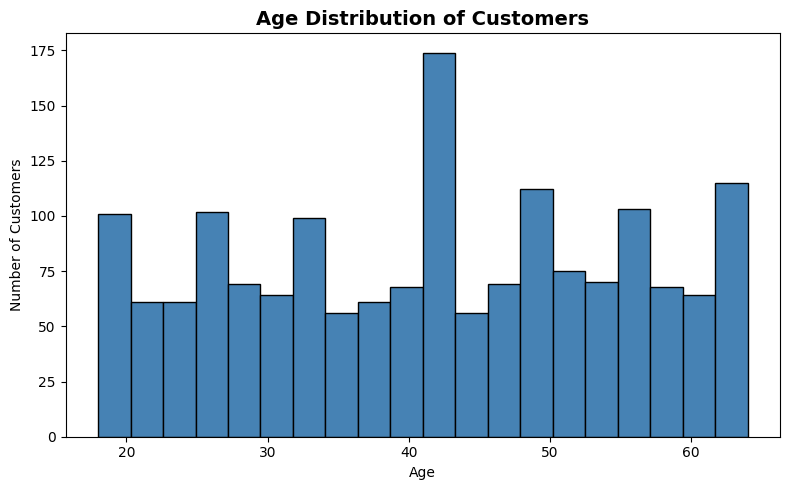

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(df2["age"], bins=20, color="steelblue", edgecolor="black")
plt.title("Age Distribution of Customers", fontsize=14, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Visual 2️⃣ — Monthly Fee Distribution (Histogram)
> **Pricing spread & skewness**

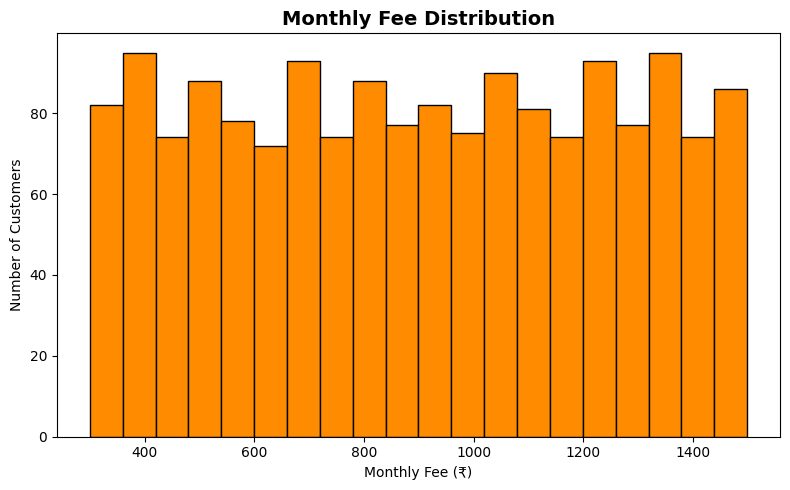

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(df2["monthly_fee"], bins=20, color="darkorange", edgecolor="black")
plt.title("Monthly Fee Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Monthly Fee (₹)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Visual 3️⃣ — Total Revenue Distribution (Histogram)
> **Revenue concentration**

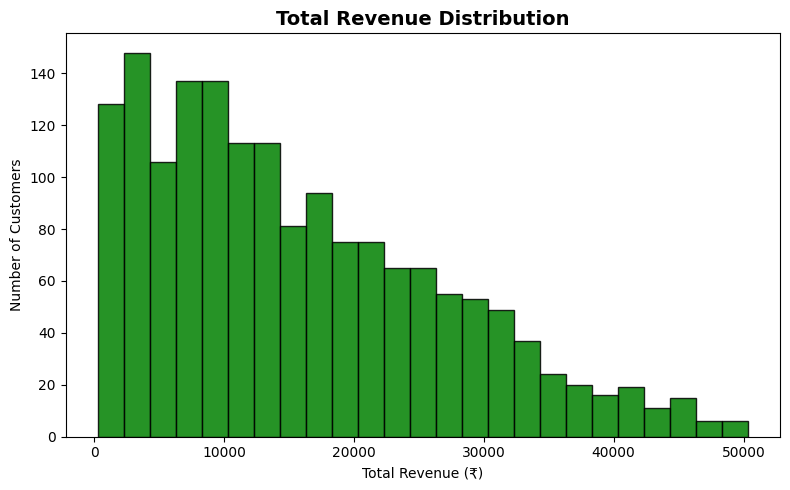

In [35]:
plt.figure(figsize=(8, 5))
plt.hist(df2["total_revenue"], bins=25, color="green", edgecolor="black", alpha=0.85)
plt.title("Total Revenue Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue (₹)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Visual 4️⃣ — Avg Session Time Distribution (Boxplot)
> **Outliers & engagement spread**

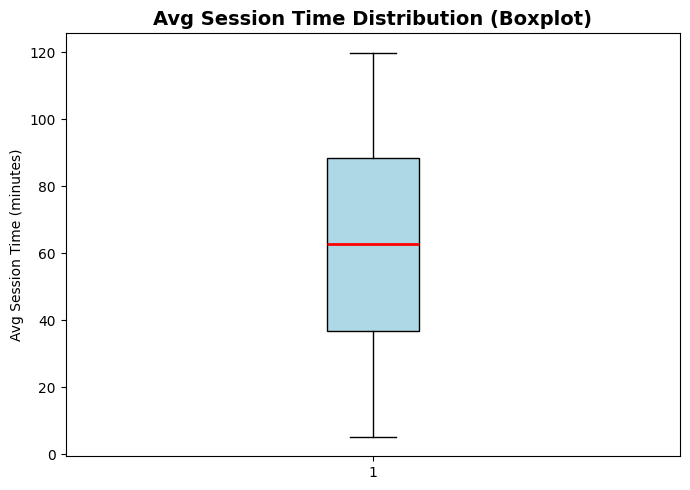

Mean   : 63.05 min
Median : 62.72 min
Std Dev: 31.60 min


In [36]:
plt.figure(figsize=(7, 5))
plt.boxplot(df2["avg_session_time"], patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="black"),
            medianprops=dict(color="red", linewidth=2),
            flierprops=dict(marker="o", color="gray", alpha=0.5))
plt.title("Avg Session Time Distribution (Boxplot)", fontsize=14, fontweight="bold")
plt.ylabel("Avg Session Time (minutes)")
plt.tight_layout()
plt.show()

print(f"Mean   : {df2['avg_session_time'].mean():.2f} min")
print(f"Median : {df2['avg_session_time'].median():.2f} min")
print(f"Std Dev: {df2['avg_session_time'].std():.2f} min")

---

## 📊 B. Categorical Insights (4 Visuals)
> *These answer who and what drives outcomes.*

### Visual 5️⃣ — Revenue by Plan Type (Bar Chart)
> **Which plan is most valuable?**

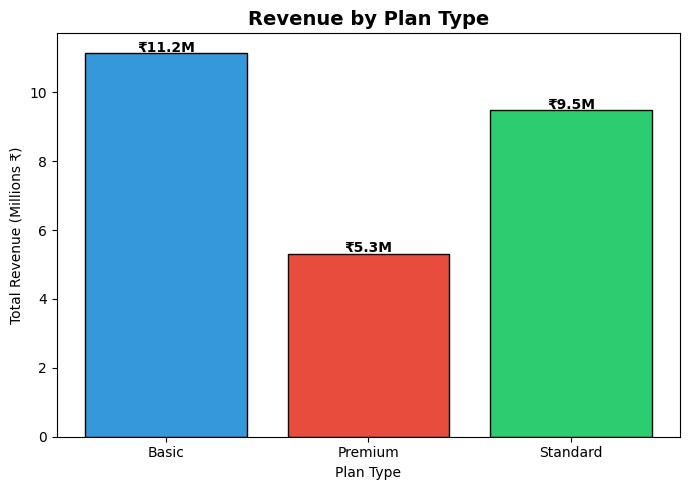

In [43]:
revenue_by_plan = df2.groupby("plan_type")["total_revenue"].sum()

plt.figure(figsize=(7, 5))
bars = plt.bar(revenue_by_plan.index, revenue_by_plan.values / 1e6,
               color=["#3498db", "#e74c3c", "#2ecc71"], edgecolor="black")
plt.title("Revenue by Plan Type", fontsize=14, fontweight="bold")
plt.xlabel("Plan Type")
plt.ylabel("Total Revenue (Millions ₹)")
for bar, val in zip(bars, revenue_by_plan.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
             f"₹{val/1e6:.1f}M", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### Visual 6️⃣ — Churn Rate by Plan Type (Bar Chart)
> **Which plans churn more?**

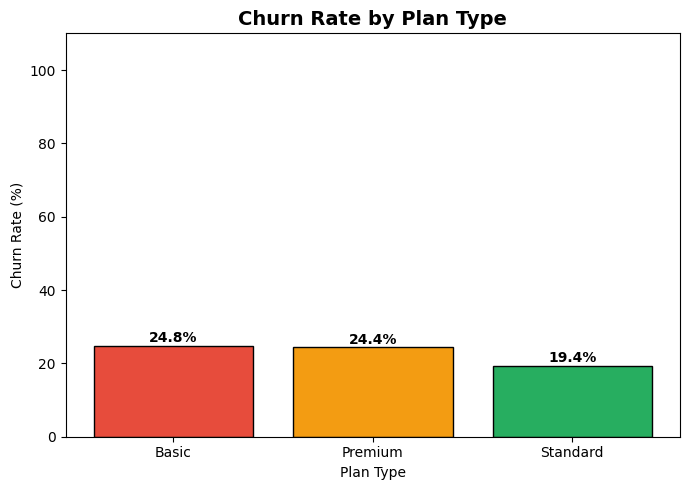

In [44]:
churn_rate = df2.groupby("plan_type")["churn_flag"].mean() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(churn_rate.index, churn_rate.values,
               color=["#e74c3c", "#f39c12", "#27ae60"], edgecolor="black")
plt.title("Churn Rate by Plan Type", fontsize=14, fontweight="bold")
plt.xlabel("Plan Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 110)
for bar, val in zip(bars, churn_rate.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{val:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### Visual 7️⃣ — Revenue by Marketing Channel (Bar Chart)
> **Best acquisition source**

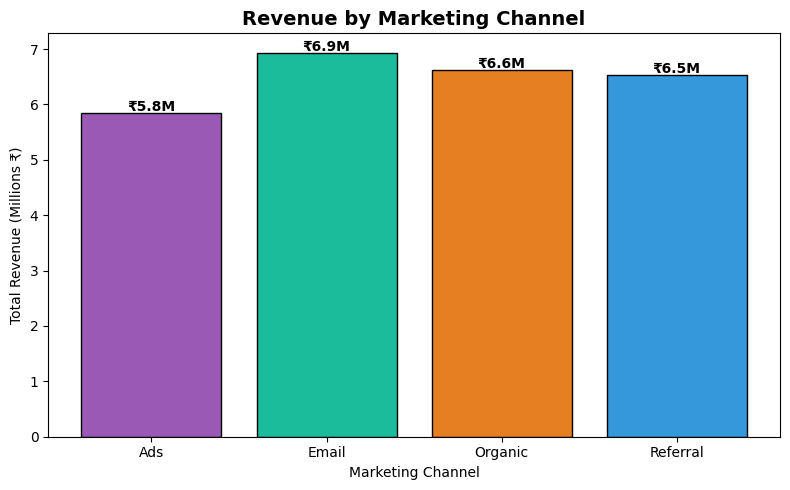

In [46]:
rv_by_channel = df2.groupby("marketing_channel")["total_revenue"].sum()

plt.figure(figsize=(8, 5))
bars = plt.bar(rv_by_channel.index, rv_by_channel.values / 1e6,
               color=["#9b59b6", "#1abc9c", "#e67e22", "#3498db"], edgecolor="black")
plt.title("Revenue by Marketing Channel", fontsize=14, fontweight="bold")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Revenue (Millions ₹)")
for bar, val in zip(bars, rv_by_channel.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
             f"₹{val/1e6:.1f}M", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

### Visual 8️⃣ — Revenue by City — Top 5 (Bar Chart)
> **Geographic contribution**

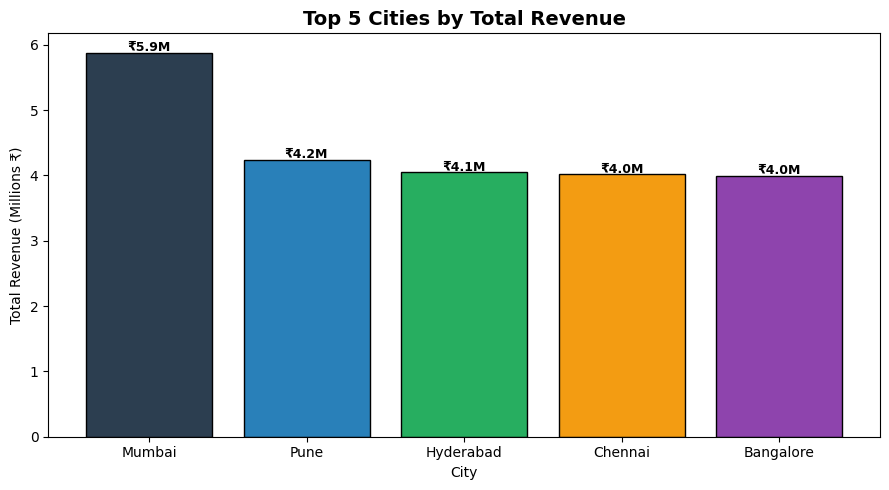

In [47]:
top5_cities = (
    df2.groupby("city")["total_revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(9, 5))
bars = plt.bar(top5_cities.index, top5_cities.values / 1e6,
               color=["#2c3e50","#2980b9","#27ae60","#f39c12","#8e44ad"], edgecolor="black")
plt.title("Top 5 Cities by Total Revenue", fontsize=14, fontweight="bold")
plt.xlabel("City")
plt.ylabel("Total Revenue (Millions ₹)")
for bar, val in zip(bars, top5_cities.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"₹{val/1e6:.1f}M", ha="center", fontweight="bold", fontsize=9)
plt.tight_layout()
plt.show()

---

## 📊 C. Behavioral & Time-Based Trends (4 Visuals)
> *These show patterns and relationships.*

### Visual 9️⃣ — Revenue vs Tenure (Scatter + Regression Line)
> **Does loyalty pay?**

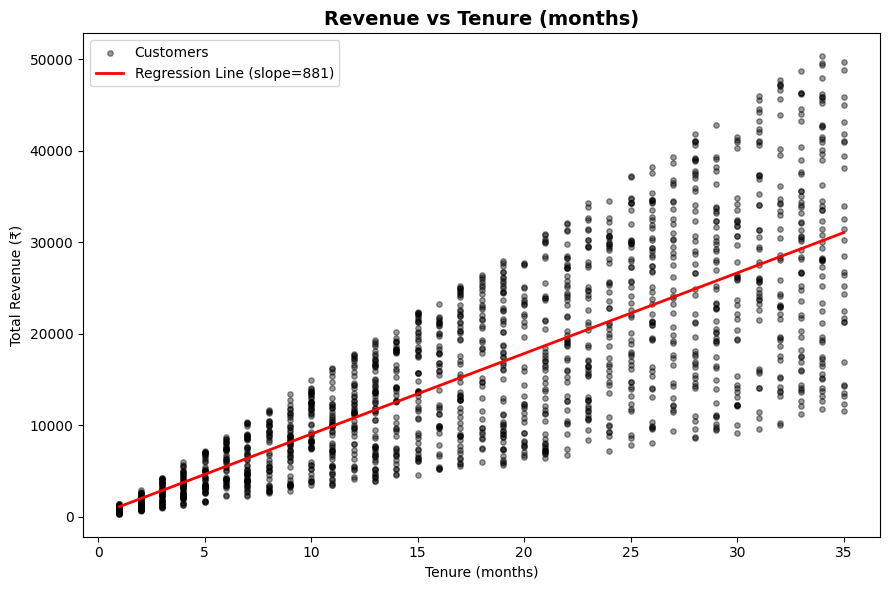

In [48]:
from numpy.polynomial.polynomial import polyfit

x = df2["tenure_months"].values
y = df2["total_revenue"].values

# Regression line
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(9, 6))
plt.scatter(x, y, color="black", alpha=0.4, s=15, label="Customers")
plt.plot(sorted(x), [m * xi + b for xi in sorted(x)],
         color="red", linewidth=2, label=f"Regression Line (slope={m:.0f})")
plt.title("Revenue vs Tenure (months)", fontsize=14, fontweight="bold")
plt.xlabel("Tenure (months)")
plt.ylabel("Total Revenue (₹)")
plt.legend()
plt.tight_layout()
plt.show()

### Visual 🔟 — Engagement Score vs Revenue (Scatter)
> **Does engagement translate to money?**

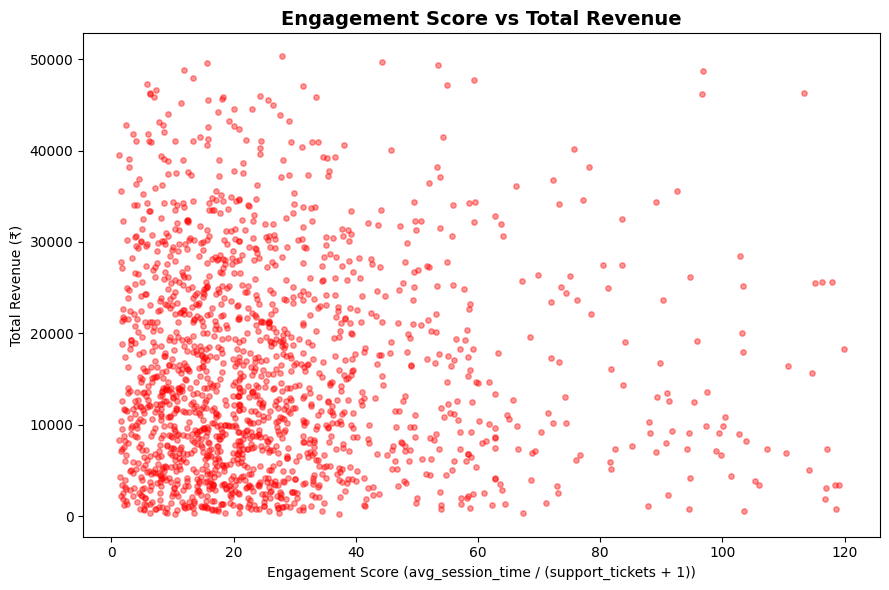

In [49]:
plt.figure(figsize=(9, 6))
plt.scatter(df2["engagement_score"], df2["total_revenue"],
            color="red", alpha=0.4, s=15)
plt.title("Engagement Score vs Total Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Engagement Score (avg_session_time / (support_tickets + 1))")
plt.ylabel("Total Revenue (₹)")
plt.tight_layout()
plt.show()

### Visual 1️⃣1️⃣ — Signup Trend Over Time (Line Chart)
> **Growth pattern**

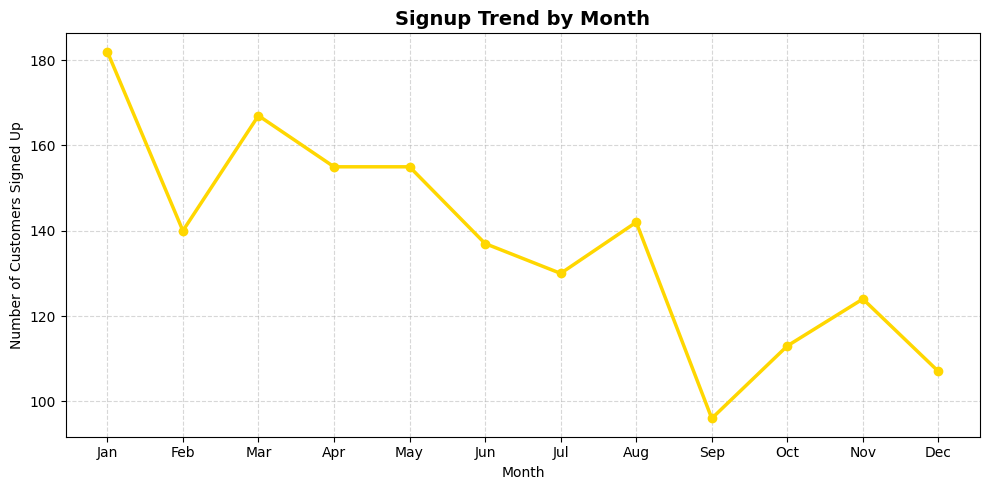

In [50]:
signup_trend = (
    df2.groupby("signup_month")["customer_id"]
    .count()
    .reset_index()
    .rename(columns={"customer_id": "num_customers"})
)

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(10, 5))
plt.plot(signup_trend["signup_month"], signup_trend["num_customers"],
         color="gold", linewidth=2.5, marker="o", markersize=6)
plt.xticks(ticks=range(1, 13), labels=month_labels)
plt.title("Signup Trend by Month", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Customers Signed Up")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Visual 1️⃣2️⃣ — Monthly Revenue Trend (Line Chart)
> **Seasonality & trend**

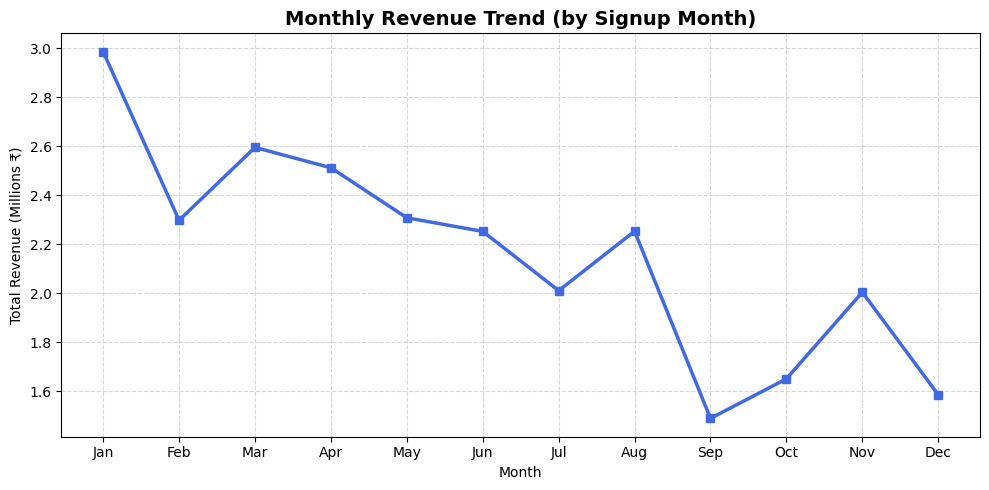

In [51]:
monthly_revenue = (
    df2.groupby("signup_month")["total_revenue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue["signup_month"], monthly_revenue["total_revenue"] / 1e6,
         color="royalblue", linewidth=2.5, marker="s", markersize=6)
plt.xticks(ticks=range(1, 13), labels=month_labels)
plt.title("Monthly Revenue Trend (by Signup Month)", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Revenue (Millions ₹)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---

## 📊 Modeling Support Visuals (2 Visuals)
> *These directly support Linear Regression.*

### Visual 1️⃣3️⃣ — Correlation Heatmap
> **Feature selection — which features are most correlated with revenue?**

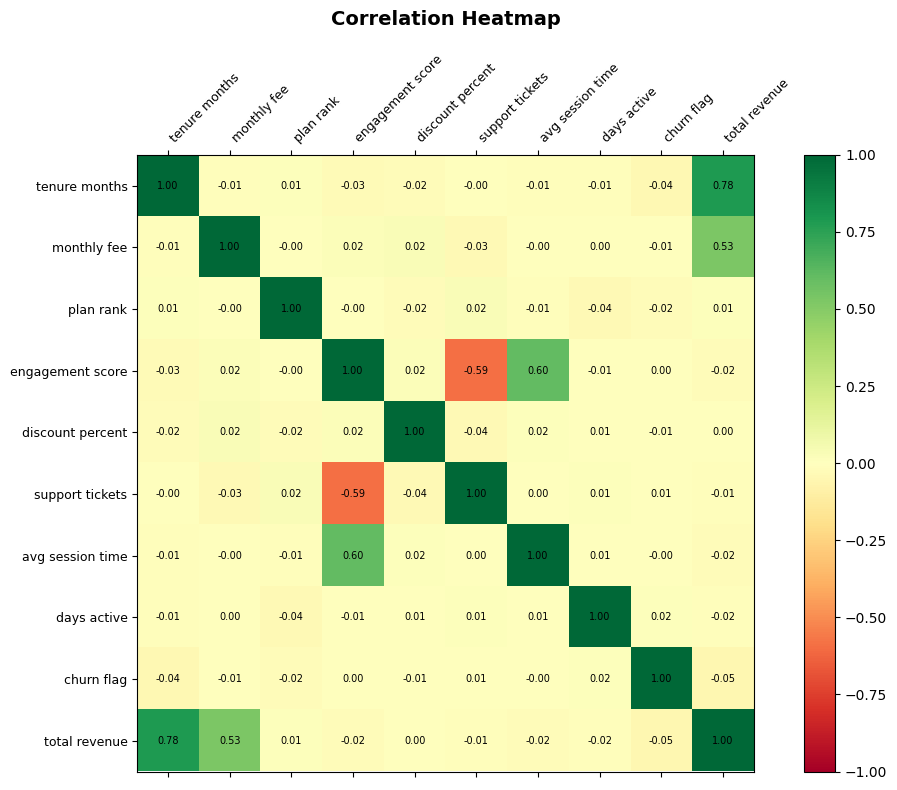


Top correlations with total_revenue:
tenure_months       0.784650
monthly_fee         0.530798
churn_flag         -0.047374
avg_session_time   -0.022295
engagement_score   -0.016910
days_active        -0.015571
support_tickets    -0.013997
plan_rank           0.011515
discount_percent    0.000711


In [52]:
corr_cols = ["tenure_months", "monthly_fee", "plan_rank",
             "engagement_score", "discount_percent", "support_tickets",
             "avg_session_time", "days_active", "churn_flag", "total_revenue"]

corr_matrix = df2[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
cax = ax.matshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
fig.colorbar(cax)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels([c.replace("_"," ") for c in corr_cols], rotation=45, ha="left", fontsize=9)
ax.set_yticklabels([c.replace("_"," ") for c in corr_cols], fontsize=9)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
                color="black")

ax.set_title("Correlation Heatmap", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

print("\nTop correlations with total_revenue:")
print(corr_matrix["total_revenue"].drop("total_revenue")
      .sort_values(key=abs, ascending=False).to_string())

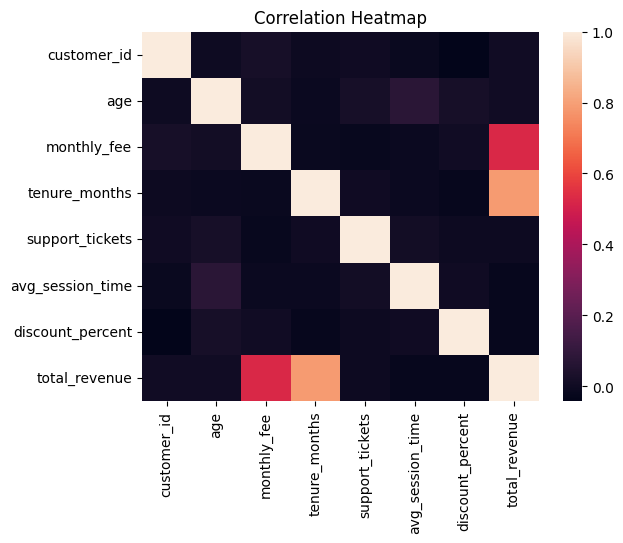

In [59]:
import seaborn as sns 
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure()
sns.heatmap(numeric_df.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()

## 7️⃣ Modeling — Linear Regression <a id='7'></a>

### Process of Making the Model
1. Filter only numeric columns with no NaN values  
2. Decide what is input (X) and output (y)  
3. Split input X → Train (80%) and Test (20%)  
4. Call the Linear Regression model  
5. Fit the model on training data  
6. See what the predicted Y values are  
7. Create scatter plot with regression line  
8. Calculate accuracy → MSE, RMSE, R²  
9. Predict revenue for new customers  


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ── Step 1: Prepare features & target ────────────────────────────────────────
model_df = df2[["tenure_months", "monthly_fee", "plan_rank",
                "engagement_score", "total_revenue"]].copy()

# Drop any rows with missing values in these columns
model_df = model_df.dropna()

print(f"Model dataset shape : {model_df.shape}")
print(f"Null values remaining: {model_df.isnull().sum().sum()}")
model_df.head()

Model dataset shape : (1648, 5)
Null values remaining: 0


,tenure_months,monthly_fee,plan_rank,engagement_score,total_revenue
0,25,1214,1,2.62,30167.90
1,22,1268,3,18.58,27642.40
2,4,783,1,41.93,3092.85
5,2,451,2,53.99,834.35
7,21,666,1,11.31,13886.10


In [54]:
# ── Step 2: Define X (input features) and y (target) ─────────────────────────
X = model_df[["tenure_months", "monthly_fee", "plan_rank", "engagement_score"]]
y = model_df["total_revenue"]

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())

Features (X):
   tenure_months  monthly_fee  plan_rank  engagement_score
0             25         1214          1              2.62
1             22         1268          3             18.58
2              4          783          1             41.93
5              2          451          2             53.99
7             21          666          1             11.31

Target (y):
0    30167.90
1    27642.40
2     3092.85
5      834.35
7    13886.10
Name: total_revenue, dtype: float64


In [55]:
# ── Step 3: Split into Train (80%) and Test (20%) ────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 1318
Testing  samples : 330


In [56]:
# ── Step 4 & 5: Create and Fit the Linear Regression model ──────────────────
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [57]:
# ── Model Coefficients ───────────────────────────────────────────────────────
# total_revenue ≈ intercept + coef1*tenure_months + coef2*monthly_fee
#               + coef3*plan_rank + coef4*engagement_score

print("Intercept:", round(lr_model.intercept_, 2))

coef_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Coefficient": lr_model.coef_.round(2)
})
print("\nCoefficients:")
print(coef_df.to_string(index=False))

Intercept: -15434.27

Coefficients:
         Feature  Coefficient
   tenure_months       880.38
     monthly_fee        17.36
       plan_rank        78.01
engagement_score        -6.13


In [60]:
# ── Step 6: Predict revenue on test data ─────────────────────────────────────
y_pred = lr_model.predict(X_test)

# Preview actual vs predicted
comparison = pd.DataFrame({
    "Actual Revenue"   : y_test.values[:10],
    "Predicted Revenue": y_pred[:10].round(2)
})
print(comparison.to_string(index=False))

 Actual Revenue  Predicted Revenue
        7651.00            9566.66
        9968.20           10824.58
       18791.00           18925.53
       26934.80           26204.60
       16612.40           19248.54
       12978.00           13747.16
        8424.00            8506.74
        3370.75            1116.44
       46248.00           37481.21
       15355.20           16288.46


In [61]:
# ── Step 8: Calculate Accuracy Metrics ───────────────────────────────────────
mse  = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2   = r2_score(y_test, y_pred)

print("=" * 45)
print("  Model Performance Metrics")
print("=" * 45)
print(f"  Mean Squared Error  (MSE)  : {mse:,.2f}")
print(f"  Root MSE            (RMSE) : {rmse:,.2f}")
print(f"  R-Squared           (R²)   : {r2:.4f}")
print("=" * 45)
print(f"\n  Interpretation:")
print(f"  → Model explains {r2*100:.1f}% of the variance in revenue")
print(f"  → Average prediction error: ₹{rmse:,.0f}")

  Model Performance Metrics
  Mean Squared Error  (MSE)  : 11,739,860.45
  Root MSE            (RMSE) : 3,426.35
  R-Squared           (R²)   : 0.9184

  Interpretation:
  → Model explains 91.8% of the variance in revenue
  → Average prediction error: ₹3,426


### Visual 1️⃣4️⃣ — Actual vs Predicted Revenue (Scatter)
> **Model performance visualization**

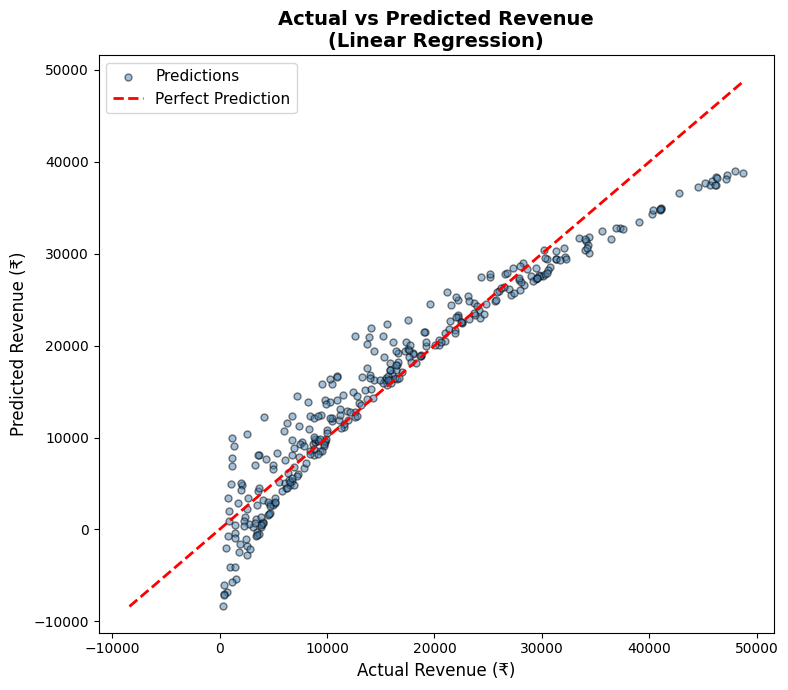

R² = 0.9184 → Model captures 91.8% of revenue variation


In [62]:
plt.figure(figsize=(8, 7))
plt.scatter(y_test, y_pred, alpha=0.5, color="steelblue",
            edgecolors="black", s=25, label="Predictions")

# Perfect prediction line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         "r--", linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual Revenue (₹)", fontsize=12)
plt.ylabel("Predicted Revenue (₹)", fontsize=12)
plt.title("Actual vs Predicted Revenue\n(Linear Regression)", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"R² = {r2:.4f} → Model captures {r2*100:.1f}% of revenue variation")

## 8️⃣ Predict Revenue for a New Customer <a id='8'></a>

In [63]:
# ── Example new customer ─────────────────────────────────────────────────────
new_customer = pd.DataFrame({
    "tenure_months"   : [12],
    "monthly_fee"     : [3000],
    "plan_rank"       : [1],       # Basic plan
    "engagement_score": [70]
})

predicted_revenue = lr_model.predict(new_customer)

print("=" * 45)
print("  New Customer Details")
print("=" * 45)
print(f"  Tenure         : {new_customer['tenure_months'].values[0]} months")
print(f"  Monthly Fee    : ₹{new_customer['monthly_fee'].values[0]}")
print(f"  Plan           : Basic (rank = 1)")
print(f"  Engagement Sc. : {new_customer['engagement_score'].values[0]}")
print("=" * 45)
print(f"  💰 Predicted Revenue : ₹{predicted_revenue[0]:,.2f}")
print("=" * 45)

  New Customer Details
  Tenure         : 12 months
  Monthly Fee    : ₹3000
  Plan           : Basic (rank = 1)
  Engagement Sc. : 70
  💰 Predicted Revenue : ₹46,865.42


---

## 📌 Project Summary

| Stage | What Was Done |
|---|---|
| **Problem Statement** | Defined business context, objectives, key questions & expected outcomes |
| **Data Loading** | Loaded `subscription_data.csv` — 2,560 rows × 15 columns |
| **Data Cleaning** | Imputed 4 columns (median/mean/mode), removed illogical dates & duplicates |
| **Feature Engineering** | Created 14 new columns (age group, tenure years, engagement score, plan rank, etc.) |
| **EDA Visuals (14)** | Distribution (4) + Categorical (4) + Behavioral/Time (4) + Modeling Support (2) |
| **Model** | Linear Regression — predicts `total_revenue` |
| **Metrics** | MSE, RMSE, R² + Actual vs Predicted scatter plot |
| **Prediction** | Revenue prediction for a new customer using trained model |

---

### 💡 Key Insights
- **Plan type** significantly impacts revenue — Premium plans generate the most  
- **Tenure** is positively correlated with revenue — loyal customers pay more  
- **Engagement score** captures the quality of interaction (high session time + low tickets = better)  
- **Marketing channel** affects lifetime value — Referral & Organic tend to bring higher-value customers  
